#  01 Data preprocessing and Subject based split


In [2]:
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

#paths
CSV_PATH     = Path("../data/driver_imgs_list.csv")
IMGS_DIR     = Path("../data/imgs")   # raw state farm images
OLD_DATA_DIR = Path("../data/statefarm_cls")    # existing random split
NEW_DATA_DIR = Path("../data/statefarm_subject_split") # outputsubject based split

VAL_SUBJECT_FRAC = 0.20   # 20% drivers to validation
SEED             = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print(df.head(8).to_string())

print(f"\nunique subjects : {df['subject'].nunique()}")
print(f"all subjects    : {sorted(df['subject'].unique())}")
print(f"\nUnique classes  : {df['classname'].nunique()}")
print(f"all classes     : {sorted(df['classname'].unique())}")

print("\nimages per subject:")
print(df.groupby('subject')['img'].count().to_string())

CSV shape: (22424, 3)
  subject classname            img
0    p002        c0  img_44733.jpg
1    p002        c0  img_72999.jpg
2    p002        c0  img_25094.jpg
3    p002        c0  img_69092.jpg
4    p002        c0  img_92629.jpg
5    p002        c0   img_3370.jpg
6    p002        c0  img_67639.jpg
7    p002        c0  img_58560.jpg

unique subjects : 26
all subjects    : ['p002', 'p012', 'p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p026', 'p035', 'p039', 'p041', 'p042', 'p045', 'p047', 'p049', 'p050', 'p051', 'p052', 'p056', 'p061', 'p064', 'p066', 'p072', 'p075', 'p081']

Unique classes  : 10
all classes     : ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']

images per subject:
subject
p002     725
p012     823
p014     876
p015     875
p016    1078
p021    1237
p022    1233
p024    1226
p026    1196
p035     848
p039     651
p041     605
p042     591
p045     724
p047     835
p049    1011
p050     790
p051     920
p052     740
p056     794
p061     809
p064     82

In [4]:
#the CSV lists filenames.

fname_to_path = {}

search_dirs = [d for d in [IMGS_DIR, OLD_DATA_DIR] if d.exists()]
for search_dir in search_dirs:
    for img_path in search_dir.rglob("*.jpg"):
        fname_to_path[img_path.name] = img_path
    for img_path in search_dir.rglob("*.png"):
        fname_to_path[img_path.name] = img_path

print(f"Total unique image files found : {len(fname_to_path)}")

#match CSV rows to actual files
df['abs_path'] = df['img'].map(fname_to_path)
matched   = df['abs_path'].notna().sum()
unmatched = df['abs_path'].isna().sum()

print(f"CSV rows matched to files      : {matched}")
print(f"CSV rows with no file found    : {unmatched}")

if unmatched > 0:
    print("\nsample unmatched filenames:")
    print(df[df['abs_path'].isna()]['img'].head(5).tolist())
    print("\n check if path is correct.")
else:
    print("\n all CSV entries matched to image files.")

#drop unmatched rows
df = df[df['abs_path'].notna()].copy()
print(f"Working with {len(df)} matched images.")

Total unique image files found : 102150
CSV rows matched to files      : 22424
CSV rows with no file found    : 0

 all CSV entries matched to image files.
Working with 22424 matched images.


In [5]:
all_subjects = sorted(df['subject'].unique())
n_val        = max(1, round(len(all_subjects) * VAL_SUBJECT_FRAC))

shuffled = all_subjects.copy()
random.shuffle(shuffled)

val_subjects   = set(shuffled[:n_val])
train_subjects = set(shuffled[n_val:])

print(f"total subjects  : {len(all_subjects)}")
print(f"train subjects  : {len(train_subjects)}  →  {sorted(train_subjects)}")
print(f"val subjects    : {len(val_subjects)}    →  {sorted(val_subjects)}")

#assign split column
df['split'] = df['subject'].apply(lambda s: 'val' if s in val_subjects else 'train')

print("\nimage count:")
print(df['split'].value_counts().to_string())

print("\nimage count by split by class:")
pivot = df.groupby(['split', 'classname'])['img'].count().unstack(fill_value=0)
print(pivot.to_string())

#verifying zero overlap
overlap = train_subjects & val_subjects
assert len(overlap) == 0, f"ERROR: Subject overlap found: {overlap}"
print("\nzero subject overlap between train and val.")

total subjects  : 26
train subjects  : 21  →  ['p002', 'p012', 'p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p026', 'p039', 'p041', 'p045', 'p047', 'p049', 'p051', 'p052', 'p061', 'p064', 'p066', 'p072', 'p075']
val subjects    : 5    →  ['p035', 'p042', 'p050', 'p056', 'p081']

image count:
split
train    18578
val       3846

image count by split by class:
classname    c0    c1    c2    c3    c4    c5    c6    c7    c8    c9
split                                                                
train      2032  1912  1941  1940  1937  1911  1931  1624  1587  1763
val         457   355   376   406   389   401   394   378   324   366

zero subject overlap between train and val.


In [7]:
#safety check
if NEW_DATA_DIR.exists():
    print(f" {NEW_DATA_DIR} already exists.")
    response = input("delete and remake (yes/no): ").strip().lower()
    if response == "yes":
        shutil.rmtree(NEW_DATA_DIR)
        print(" old folder is deleted.")
    else:
        print(" keeping existing folder. Skipping copy step.")
        import sys; sys.exit(0)

print(f"\nBuilding {NEW_DATA_DIR} ...")
print("(copying images)\n")

copied = defaultdict(lambda: defaultdict(int))
errors = []

for _, row in df.iterrows():
    src  = Path(row['abs_path'])
    dest = NEW_DATA_DIR / row['split'] / row['classname'] / src.name
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy2(src, dest)
        copied[row['split']][row['classname']] += 1
    except Exception as e:
        errors.append((src, e))

print("\n done")
print(f"\n{'split':8s} {'class':25s} {'images':>8s}")
print("-" * 46)
for split_name in ['train', 'val']:
    total = 0
    for cls_name in sorted(copied[split_name]):
        n = copied[split_name][cls_name]
        print(f"  {split_name:8s} {cls_name:25s} {n:>6d}")
        total += n
    print(f"  {split_name:8s} {'TOTAL':25s} {total:>6d}")
    print()

if errors:
    print(f" {len(errors)} copy errors — first 5:")
    for src, e in errors[:5]:
        print(f"   {src}: {e}")

 ../data/statefarm_subject_split already exists.
 keeping existing folder. Skipping copy step.


SystemExit: 0

In [ ]:

grand_total = 0
for split in ['train', 'val']:
    split_dir = NEW_DATA_DIR / split
    split_total = 0
    print(f"\n  {split}/")
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))
            print(f"    {cls_dir.name:25s} {n:>6d} images")
            split_total += n
    print(f"    {'── TOTAL':25s} {split_total:>6d} images")
    grand_total += split_total

train_total = sum(
    len(list(d.glob('*.jpg')) + list(d.glob('*.png')))
    for d in (NEW_DATA_DIR / 'train').iterdir() if d.is_dir()
)
val_total = grand_total - train_total

print(f"\n  total : {grand_total}")
print(f"  Val %       : {val_total / grand_total:.1%}")

Final folder structure:

  train/
    c0                          2032 images
    c1                          1912 images
    c2                          1941 images
    c3                          1940 images
    c4                          1937 images
    c5                          1911 images
    c6                          1931 images
    c7                          1624 images
    c8                          1587 images
    c9                          1763 images
    ── TOTAL                   18578 images

  val/
    c0                           457 images
    c1                           355 images
    c2                           376 images
    c3                           406 images
    c4                           389 images
    c5                           401 images
    c6                           394 images
    c7                           378 images
    c8                           324 images
    c9                           366 images
    ── TOTAL                    38

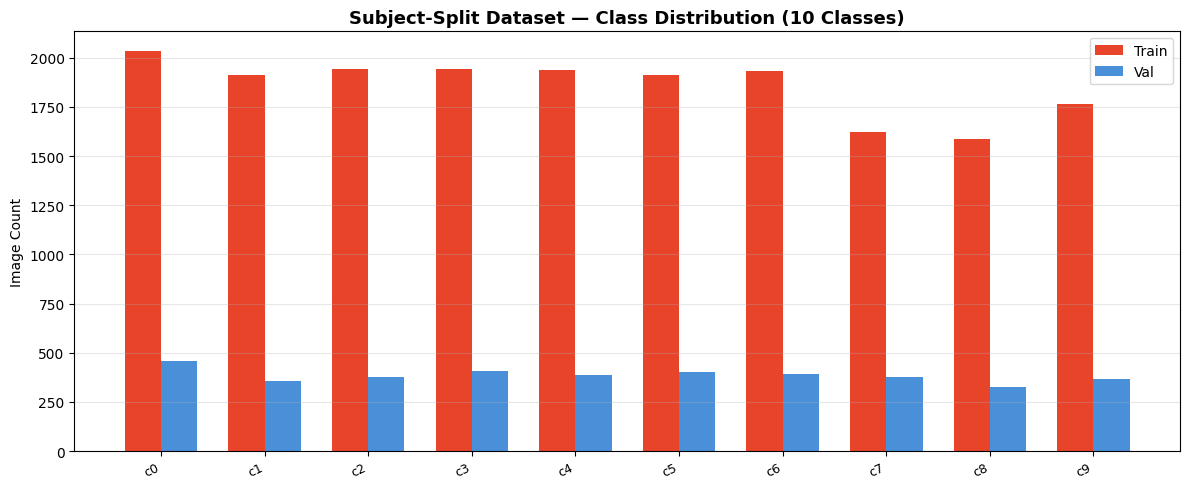

 Saved to reports/class_distribution_subject_split.png


In [8]:
counts = {'train': {}, 'val': {}}
for split in ['train', 'val']:
    for cls_dir in sorted((NEW_DATA_DIR / split).iterdir()):
        if cls_dir.is_dir():
            counts[split][cls_dir.name] = len(
                list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
            )

classes = sorted(counts['train'].keys())
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, [counts['train'].get(c, 0) for c in classes], width, label='Train', color='#E8442A')
ax.bar(x + width/2, [counts['val'].get(c, 0)   for c in classes], width, label='Val',   color='#4A90D9')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=25, ha='right', fontsize=9)
ax.set_title('Subject-Split Dataset — Class Distribution (10 Classes)', fontsize=13, fontweight='bold')
ax.set_ylabel('Image Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/class_distribution_subject_split.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved to reports/class_distribution_subject_split.png')